# 🧠 Derin Ogrenme ile Goruntu Isleme: CNN, U-Net ve Mask R-CNNBu not defteri, goruntu islemede en cok kullanilan uc derin ogrenme mimarisini**kavramsal aciklama + satir satir yorumlanmis kod** formatinda ele alir:1. **CNN (Convolutional Neural Network)** — Goruntu siniflandirma2. **U-Net** — Piksel bazli segmentasyon3. **Mask R-CNN** — Nesne tespiti + ornek segmentasyonu> **Veri Seti:** CIFAR-10 (Kaggle CIFAR-10)> - 50,000 egitim + 10,000 test goruntusu> - 32x32 piksel, renkli (3 kanal - RGB)> - 10 sinif: Ucak, Araba, Kus, Kedi, Geyik, Kopek, Kurbağa, At, Gemi, Kamyon**Kutuphane:** PyTorch (	orch, 	orchvision)

In [2]:
import getpass
import os
import json
import zipfile

# Kaggle API kimlik bilgilerini sor
print("=== Kaggle API Kimlik Bilgileri ===")
print("https://www.kaggle.com -> Settings -> API -> Create New Token")
print()

kullanici_adi = input("Kaggle kullanici adinizi girin: ")
api_key = getpass.getpass("Kaggle API key girin (gizli olarak girilecek): ")

# kaggle.json dosyasini olustur
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_creds = {"username": kullanici_adi, "key": api_key}
with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
    json.dump(kaggle_creds, f)

print("\nKaggle API basariyla ayarlandi!")

=== Kaggle API Kimlik Bilgileri ===
https://www.kaggle.com -> Settings -> API -> Create New Token

Kaggle kullanici adinizi girin: https://www.kaggle.com/gamzedrn
Kaggle API key girin (gizli olarak girilecek): ··········

Kaggle API basariyla ayarlandi!


In [4]:
# 1. Kaggle kütüphanesini kur
!pip install kaggle -q

import os
import zipfile

# 2. CIFAR-10 veri setini indir
!kaggle competitions download -c cifar-10 -p ./data/cifar10 --force

# 3. Zip dosyasını çıkar
zip_yolu = './data/cifar10/cifar-10.zip'

if os.path.exists(zip_yolu):
    with zipfile.ZipFile(zip_yolu, 'r') as zip_ref:
        zip_ref.extractall('./data/cifar10')
    print("CIFAR-10 veri seti başarıyla indirildi!")
    print(f"Dosyalar: {os.listdir('./data/cifar10')}")
else:
    print("Uyarı: Zip dosyası bulunamadı.")
    print("Alternatif: torchvision ile otomatik indirilecek.")

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles
Uyarı: Zip dosyası bulunamadı.
Alternatif: torchvision ile otomatik indirilecek.


In [5]:
# Gerekli kutuphaneleri yukluyoruz
!pip install torch torchvision --quiet

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# Sonuçların tekrarlanabilir olması için rastgelelik tohumu (seed) sabitleyelim
torch.manual_seed(42)

# Ekran kartı (GPU) varsa CUDA'yı, yoksa işlemciyi (CPU) seçelim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cpu


## 📂 CIFAR-10 Veri Setini Yukle

In [7]:
# CIFAR-10 sınıf isimleri
SINIF_ISIMLERI = ('ucak', 'araba', 'kus', 'kedi', 'geyik',
                  'kopek', 'kurbağa', 'at', 'gemi', 'kamyon')

# Veri dönüşümü ve yükleme (Eğitim için veri artırımı içerir)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Veri setlerini indir ve yükle
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)

# DataLoader'ları oluştur
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

print(f"Eğitim örnek sayısı: {len(trainset)}")
print(f"Test örnek sayısı: {len(testset)}")

100%|██████████| 170M/170M [43:40<00:00, 65.1kB/s]


Eğitim örnek sayısı: 50000
Test örnek sayısı: 10000


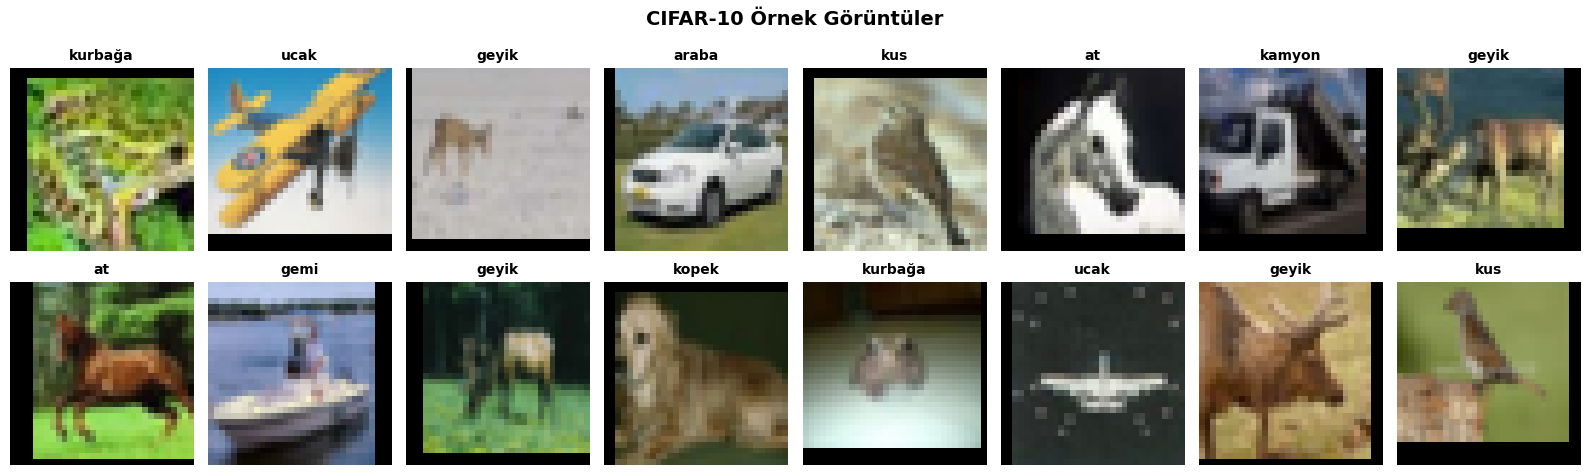

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Resimleri orijinal renklerine geri getirmek için fonksiyon
def imshow(img):
    # Kullandığımız özel normalizasyon değerlerini geri alıyoruz (Unnormalize)
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])

    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1) # Renk değerlerini 0-1 arasında tutalım
    return img

# Veri yükleyiciden bir paket (batch) resim çekelim
dataiter = iter(trainloader)
images, labels = next(dataiter)

# 2 satır ve 8 sütundan oluşan bir tablo oluşturup resimleri çizdirelim
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(imshow(images[i]))
        ax.set_title(SINIF_ISIMLERI[labels[i]], fontsize=10, fontweight='semibold')
    ax.axis('off')

plt.suptitle("CIFAR-10 Örnek Görüntüler", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

---
## 1. CNN (Convolutional Neural Network / Evrisimli Sinir Agi)

### Konu Anlatimi

CNN, ozellikle goruntu verisi icin tasarlanmis bir sinir agi turu. Klasik
tam baglantili (fully connected) aglarin aksine, goruntunun **uzamsal (spatial)
yapisini** korur ve su ucg ana bilesenden olusur:

1. **Konvolusyon (Evrisim) Katmani (`Conv2d`):**
   Kucuk bir filtre (kernel), goruntu uzerinde kaydirilarak (sliding window)
   yerel oruntuleri (kenar, kose, doku vb.) tespit eder. Her filtre bir
   "ozellik haritasi" (feature map) uretir.

2. **Havuzlama (Pooling) Katmani (`MaxPool2d`):**
   Ozellik haritalarinin boyutunu kucultur, hesaplama yukunu azaltir ve
   modeli kucuk kaymalara/gurultuye karsi daha dayanikli (invariant) yapar.

3. **Aktivasyon Fonksiyonu (`ReLU`):**
   Dogrusal olmayanlik (non-linearity) katar; boylece ag karmaşık oruntuleri
   ogrenebilir.

**Tipik kullanim alani:** Goruntu siniflandirma (bu goruntu ucak mi araba mi?).

In [9]:
class BasitCNN(nn.Module):
    """
    Basit bir görüntü sınıflandırma CNN'i.
    Giriş: (batch, 3, 32, 32) boyutunda RGB görüntü
    Çıkış: (batch, 10) boyutunda sınıf skorları (logits)
    """
    def __init__(self, num_classes=10):
        super().__init__()

        # 1. Konvolüsyon Bloğu
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # 2. Konvolüsyon Bloğu
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # 3. Konvolüsyon Bloğu
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Havuzlama (Pooling) ve Aşırı Öğrenmeyi Önleme (Dropout)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.25)

        # Tam bağlantılı katmanlar (Dense layers)
        # 3 kez pool işlemi boyutu yarıya indirir: 32 -> 16 -> 8 -> 4
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Evrişim -> Batch Norm -> Aktivasyon -> Pooling
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # Giriş 32x32 -> Çıkış 16x16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # Giriş 16x16 -> Çıkış 8x8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # Giriş 8x8 -> Çıkış 4x4

        # Düzleştirme (Matrisi vektöre çevirme)
        x = torch.flatten(x, 1)    # (batch, 128*4*4)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

# Modeli oluştur ve seçilen cihaza (GPU/CPU) gönder
model_cnn = BasitCNN(num_classes=10).to(device)
print(model_cnn)

# Toplam parametre sayısını hesapla
toplam_param = sum(p.numel() for p in model_cnn.parameters())
print(f"\nToplam parametre sayısı: {toplam_param:,}")

BasitCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Toplam parametre sayısı: 620,810


In [10]:
# Kayıp fonksiyonu ve optimizer (Adam Optimizer, Öğrenme Oranı = 0.001)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=1e-3)

# Eğitim fonksiyonu (Tek bir çağ/epoch için)
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    toplam_kayip = 0
    dogru = 0
    toplam = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Gradyanları sıfırla
        optimizer.zero_grad()
        # İleri besleme (Forward pass)
        cikti = model(images)
        loss = criterion(cikti, labels)
        # Geriye yayılım (Backward pass)
        loss.backward()
        # Ağırlıkları güncelle
        optimizer.step()

        toplam_kayip += loss.item()
        _, tahmin = torch.max(cikti, 1)
        dogru += (tahmin == labels).sum().item()
        toplam += labels.size(0)

    return toplam_kayip / len(loader), dogru / toplam

# Değerlendirme fonksiyonu (Test kümesi için)
def evaluate(model, loader, criterion, device):
    model.eval()
    toplam_kayip = 0
    dogru = 0
    toplam = 0

    # Test sırasında gradyan hesaplamaya gerek yok (Hafıza ve hız kazandırır)
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            cikti = model(images)
            loss = criterion(cikti, labels)

            toplam_kayip += loss.item()
            _, tahmin = torch.max(cikti, 1)
            dogru += (tahmin == labels).sum().item()
            toplam += labels.size(0)

    return toplam_kayip / len(loader), dogru / toplam

# Eğitim döngüsü
print("Eğitim başlıyor...")
n_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch(model_cnn, trainloader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model_cnn, testloader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch+1}/{n_epochs}: "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc*100:.2f}%")

print("\nEğitim tamamlandı!")

Eğitim başlıyor...
Epoch 1/10: Train Loss: 1.4837 Acc: 45.66% | Test Loss: 1.1364 Acc: 58.82%
Epoch 2/10: Train Loss: 1.1369 Acc: 58.88% | Test Loss: 0.9583 Acc: 65.90%
Epoch 3/10: Train Loss: 0.9963 Acc: 64.34% | Test Loss: 0.8949 Acc: 68.16%
Epoch 4/10: Train Loss: 0.9106 Acc: 67.85% | Test Loss: 0.7585 Acc: 73.19%
Epoch 5/10: Train Loss: 0.8512 Acc: 69.97% | Test Loss: 0.7281 Acc: 74.11%
Epoch 6/10: Train Loss: 0.8123 Acc: 71.57% | Test Loss: 0.6896 Acc: 76.02%
Epoch 7/10: Train Loss: 0.7657 Acc: 73.22% | Test Loss: 0.7334 Acc: 74.06%
Epoch 8/10: Train Loss: 0.7437 Acc: 74.09% | Test Loss: 0.6752 Acc: 76.59%
Epoch 9/10: Train Loss: 0.7127 Acc: 75.15% | Test Loss: 0.6199 Acc: 78.33%
Epoch 10/10: Train Loss: 0.6908 Acc: 75.84% | Test Loss: 0.6403 Acc: 77.62%

Eğitim tamamlandı!


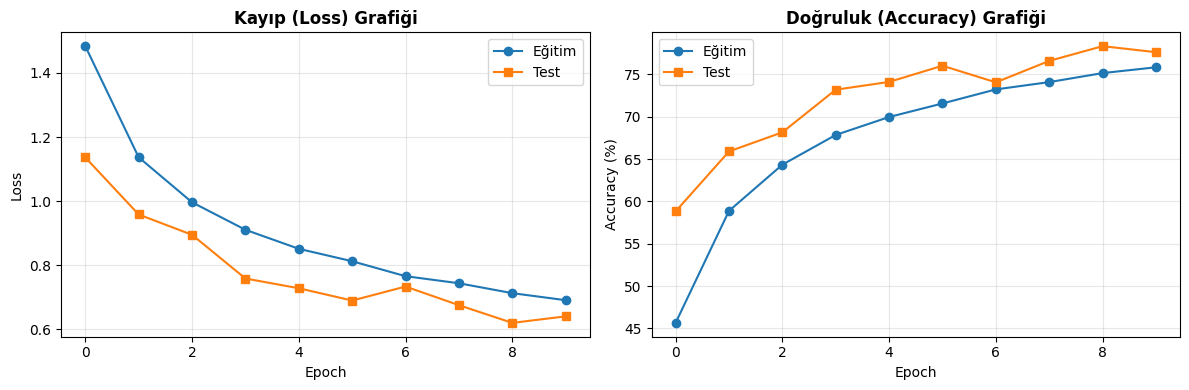

In [11]:
# Eğitim grafiklerini çizdirelim
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 1. Kayıp (Loss) Grafiği
ax1.plot(history['train_loss'], label='Eğitim', marker='o')
ax1.plot(history['test_loss'], label='Test', marker='s')
ax1.set_title('Kayıp (Loss) Grafiği', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Doğruluk (Accuracy) Grafiği
ax2.plot([a*100 for a in history['train_acc']], label='Eğitim', marker='o')
ax2.plot([a*100 for a in history['test_acc']], label='Test', marker='s')
ax2.set_title('Doğruluk (Accuracy) Grafiği', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2. U-Net

### Konu Anlatimi

U-Net, orijinal olarak tibbi goruntu segmentasyonu icin gelistirilmis, ancak
gunumuzde her turlu **piksel bazli segmentasyon** gorevinde kullanilan bir
mimarisidir. Adini, agin "U" harfine benzeyen simetrik yapısindan alir.

Iki ana yoldan olusur:

1. **Daraltma Yolu (Encoder / Contracting Path):**
   Klasik bir CNN gibi calisir: art arda konvolusyon + havuzlama katmanlari
   ile goruntunun **uzamsal boyutu kuculur** ama **kanal (ozellik) sayisi
   artar**.

2. **Genisletme Yolu (Decoder / Expanding Path):**
   Ters islem uygulanir: transpoze konvolusyon (upsampling) ile uzamsal
   boyut tekrar buyutulur.

3. **Atlama Baglantilari (Skip Connections):**
   U-Net'in en kritik ozelligi budur. Encoder'daki her seviyenin cikisi,
   decoder'daki ayni seviyeye **dogrudan baglanir (concatenate)**.

**Cikti:** Girdiyle ayni boyutta (H x W), her pikselin hangi sinifa ait
oldugunu gosteren bir "maske" (segmentasyon haritasi).

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlok(nn.Module):
    """
    U-Net'te tekrar tekrar kullanılan temel yapı taşı:
    (Konvolüsyon -> BatchNorm -> ReLU) x 2
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.blok = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.blok(x)

class UNet(nn.Module):
    """
    Basitleştirilmiş U-Net mimarisi.
    Giriş : (batch, in_ch, H, W)
    Çıkış : (batch, num_classes, H, W)
    """
    def __init__(self, in_ch=3, num_classes=1, ozellikler=[64, 128, 256, 512]):
        super().__init__()

        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ENCODER (Aşağı Doğru Yol)
        kanal = in_ch
        for f in ozellikler:
            self.encoder.append(ConvBlok(kanal, f))
            kanal = f

        # BOTTLENECK (En Alt Köprü)
        self.bottleneck = ConvBlok(ozellikler[-1], ozellikler[-1] * 2)

        # DECODER (Yukarı Doğru Yol)
        for f in reversed(ozellikler):
            self.decoder.append(
                nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2)
            )
            self.decoder.append(ConvBlok(f * 2, f))

        self.son_katman = nn.Conv2d(ozellikler[0], num_classes, kernel_size=1)

    def forward(self, x):
        skip_baglantilari = []

        # Encoder aşaması
        for enc_blok in self.encoder:
            x = enc_blok(x)
            skip_baglantilari.append(x)
            x = self.pool(x)

        # En alt katman
        x = self.bottleneck(x)

        # Atlama bağlantılarını tersten okumak için çeviriyoruz
        skip_baglantilari = skip_baglantilari[::-1]

        # Decoder aşaması
        for i in range(0, len(self.decoder), 2):
            x = self.decoder[i](x) # Yukarı konvolüsyon (Up-conv)
            skip = skip_baglantilari[i // 2]

            # Boyut eşitleme kontrolü
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])

            # Kanalları yan yana birleştirme (Concatenation)
            x = torch.cat((skip, x), dim=1)
            x = self.decoder[i + 1](x)

        return self.son_katman(x)

# U-Net modelini oluştur ve seçilen cihaza (GPU/CPU) gönder
model_unet = UNet(in_ch=3, num_classes=10).to(device)

# Sahte bir RGB görüntü paketi (Batch) oluşturarak test edelim
sahte_goruntu = torch.randn(2, 3, 32, 32).to(device)
maske_ciktisi = model_unet(sahte_goruntu)

print(f"Giriş boyutu : {sahte_goruntu.shape}")
print(f"Çıktı boyutu : {maske_ciktisi.shape}")

toplam_param = sum(p.numel() for p in model_unet.parameters())
print(f"Toplam parametre sayısı: {toplam_param:,}")

Giriş boyutu : torch.Size([2, 3, 32, 32])
Çıktı boyutu : torch.Size([2, 10, 32, 32])
Toplam parametre sayısı: 31,044,106


---
## 3. Mask R-CNN

### Konu Anlatimi

Mask R-CNN, **nesne tespiti (object detection)** ile **ornek segmentasyonunu
(instance segmentation)** ayni anda yapan bir mimarisidir.

Mimarinin temel bileşenleri:

1. **Omurga Agi (Backbone, ornek ResNet + FPN):**
   Goruntuden cok olcekli ozellik haritalari cikarir.

2. **Bolge Oneri Agi (Region Proposal Network - RPN):**
   Goruntude nesne olabilecek aday bolgeleri onerir.

3. **RoIAlign:**
   Aday bolgeleri sabit boyutlu ozellik haritalarina donusturur.

4. **Uc Paralel Cikis Bassligi (Head):**
   - Siniflandirma bassligi
   - Kutu regresyon bassligi
   - Maske bassligi

**Tipik kullanim alani:** Otonom surus, video izleme, tibbi goruntulerde coklu hucre/lezyon tespiti.

In [13]:
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def mask_rcnn_olustur(num_classes):
    """
    COCO veri setiyle önceden eğitilmiş (pretrained) Mask R-CNN modelini yükler
    ve son katmanlarını kendi sınıf sayımıza göre değiştirir (transfer learning).

    num_classes: arkaplan dahil toplam sınıf sayısı
    """
    # Önceden eğitilmiş en güncel ağırlıklarla modeli yükle
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")

    # Sınıflandırma + Kutu Regresyon Başlığını Değiştir (Sınıf sayımıza uyarla)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Maske Tahmin Başlığını Değiştir (Piksel düzeyinde maskeleme için)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes
    )

    return model

# Örnek: arkaplan + 10 CIFAR-10 sınıfı (toplam 11 sınıf)
# Not: torchvision'ın nesne tespiti modellerinde 0. indeks her zaman arka plana (background) ayrılır.
NUM_CLASSES = 11
model_maskrcnn = mask_rcnn_olustur(NUM_CLASSES).to(device)
model_maskrcnn.eval()

print("Mask R-CNN modeli başarıyla oluşturuldu.")
print(f"Toplam parametre sayısı: {sum(p.numel() for p in model_maskrcnn.parameters()):,}")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 134MB/s]


Mask R-CNN modeli başarıyla oluşturuldu.
Toplam parametre sayısı: 43,970,833


In [14]:
# Çıkarım (Inference) Örneği
# Mask R-CNN bir liste içinde tensor listesi bekler, bu yüzden listeye aldık.
sahte_goruntu_listesi = [torch.rand(3, 300, 400).to(device)]

with torch.no_grad():
    tahminler = model_maskrcnn(sahte_goruntu_listesi)

# İlk resmin sonuçlarını alalım
tek_goruntu_sonucu = tahminler[0]

print("Çıktı anahtarları:", tek_goruntu_sonucu.keys())
print(f"Tespit edilen kutu sayısı : {tek_goruntu_sonucu['boxes'].shape}")
print(f"Maske tensör boyutu      : {tek_goruntu_sonucu['masks'].shape}")
print(f"Skor örnekleri (ilk 5)   : {tek_goruntu_sonucu['scores'][:5]}")

Çıktı anahtarları: dict_keys(['boxes', 'labels', 'scores', 'masks'])
Tespit edilen kutu sayısı : torch.Size([100, 4])
Maske tensör boyutu      : torch.Size([100, 1, 300, 400])
Skor örnekleri (ilk 5)   : tensor([0.1865, 0.1863, 0.1813, 0.1799, 0.1796])


---
## Ozet Karsilastirma

| Ozellik | CNN | U-Net | Mask R-CNN |
|---|---|---|---|
| **Gorev** | Siniflandirma | Semantik segmentasyon | Nesne tespiti + ornek segmentasyonu |
| **Cikti** | Tek etiket/goruntu | Piksel bazli sinif haritasi | Kutu + sinif + nesne bazli maske |
| **Nesneleri ayirt eder mi?** | Hayir | Hayir (ayni sinif tek maskede birlesir) | Evet (her nesne ayri) |
| **Mimari karmasikligi** | Dusuk | Orta | Yuksek |
| **Tipik kullanim** | "Bu goruntu ne?" | "Hangi piksel hangi sinifa ait?" | "Kac nesne var, nerede, sinirlari ne?" |

### Sonraki Adimlar
- Veri artirma (Data Augmentation) ekleyerek model dogrulugunu artirabilirsiniz.
- `DataLoader` kullanarak batch'ler halinde veri besleme eklenebilir.
- Egitim/dogrulama kayibi grafikleri ile model performansi izlenebilir.
- Model agirliklari `torch.save(model.state_dict(), "model.pth")` ile kaydedilebilir.
